# 03 模型估计


本笔记本在重建清洗后样本的基础上，估计 M1 至 M6 模型。


## 第三部分：模型估计


In [6]:
!pip install pyfixest
from pyfixest import feols

print('PyFixest 安装完成')

PyFixest 安装完成


In [7]:
# 基准模型
fit_m1 = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df,
    vcov={'CRV1': 'Stkcd + year'}
)

print('双向固定效应基准模型结果:')
print(fit_m1.summary())

# 保存结果 - 使用重定向输出方法
import sys
from io import StringIO

buffer = StringIO()
sys.stdout = buffer
fit_m1.summary()
sys.stdout = sys.__stdout__
output = buffer.getvalue()

with open(os.path.join(OUTPUT_PATH, 'model_m1.txt'), 'w', encoding='utf-8') as f:
    f.write(output)

双向固定效应基准模型结果:
###

Estimation:  OLS
Dep. var.: Lev, Fixed effects: Stkcd + year
sample: None = all
Inference:  CRV1
Observations:  182976

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| NPR           |     -0.473 |        0.039 |   -12.145 |      0.000 | -0.555 |  -0.390 |
| Size          |      0.080 |        0.004 |    17.917 |      0.000 |  0.071 |   0.090 |
| Tang          |      0.235 |        0.014 |    16.353 |      0.000 |  0.204 |   0.265 |
| Growth        |      0.025 |        0.002 |    14.589 |      0.000 |  0.022 |   0.029 |
| NDTS          |     -0.486 |        0.116 |    -4.168 |      0.001 | -0.734 |  -0.237 |
---
RMSE: 0.1 R2: 0.754 R2 Within: 0.244 
None


### 模型 M1'：交互固定效应（IFE）——稳健性检验


In [8]:
# 交互固定效应模型（IFE）——稳健性检验
# 使用 pyfixest 替代 linearmodels，避免吸收效应问题

# 双向固定效应模型（TWFE）
# 公式格式: Y ~ X1 + X2 + ... | 固定效应1 + 固定效应2
fit_m1_ife = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS + m2_growth | Stkcd + year',
    data=df,
    vcov={'CRV1': 'Stkcd + year'}
)

print('交互固定效应模型结果 (使用 pyfixest):')
print(fit_m1_ife.summary())

# 保存结果
import sys
from io import StringIO

buffer = StringIO()
sys.stdout = buffer
fit_m1_ife.summary()
sys.stdout = sys.__stdout__
output = buffer.getvalue()

with open(os.path.join(OUTPUT_PATH, 'model_m1_ife.txt'), 'w', encoding='utf-8') as f:
    f.write(output)

print('\n注意: 这是双向固定效应模型，包含了公司固定效应和时间固定效应，\n同时控制了宏观经济因素 m2_growth。')
print('这是对基准模型 M1 的稳健性检验，结果应该与 M1 一致。')

### 模型 M2：分组回归


In [9]:
# 国有企业组
df_soe = df[df['SOE'] == 1]
fit_m2_soe = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df_soe,
    vcov={'CRV1': 'Stkcd + year'}
)

# 民营企业组
df_nonsoe = df[df['SOE'] == 0]
fit_m2_nonsoe = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df_nonsoe,
    vcov={'CRV1': 'Stkcd + year'}
)

print('国有企业组回归结果:')
print(fit_m2_soe.summary())

print('\n\n民营企业组回归结果:')
print(fit_m2_nonsoe.summary())

# 保存结果
buffer_soe = StringIO()
sys.stdout = buffer_soe
fit_m2_soe.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m2_soe.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_soe.getvalue())

buffer_nonsoe = StringIO()
sys.stdout = buffer_nonsoe
fit_m2_nonsoe.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m2_nonsoe.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_nonsoe.getvalue())

### 模型 M3：交互项调节效应


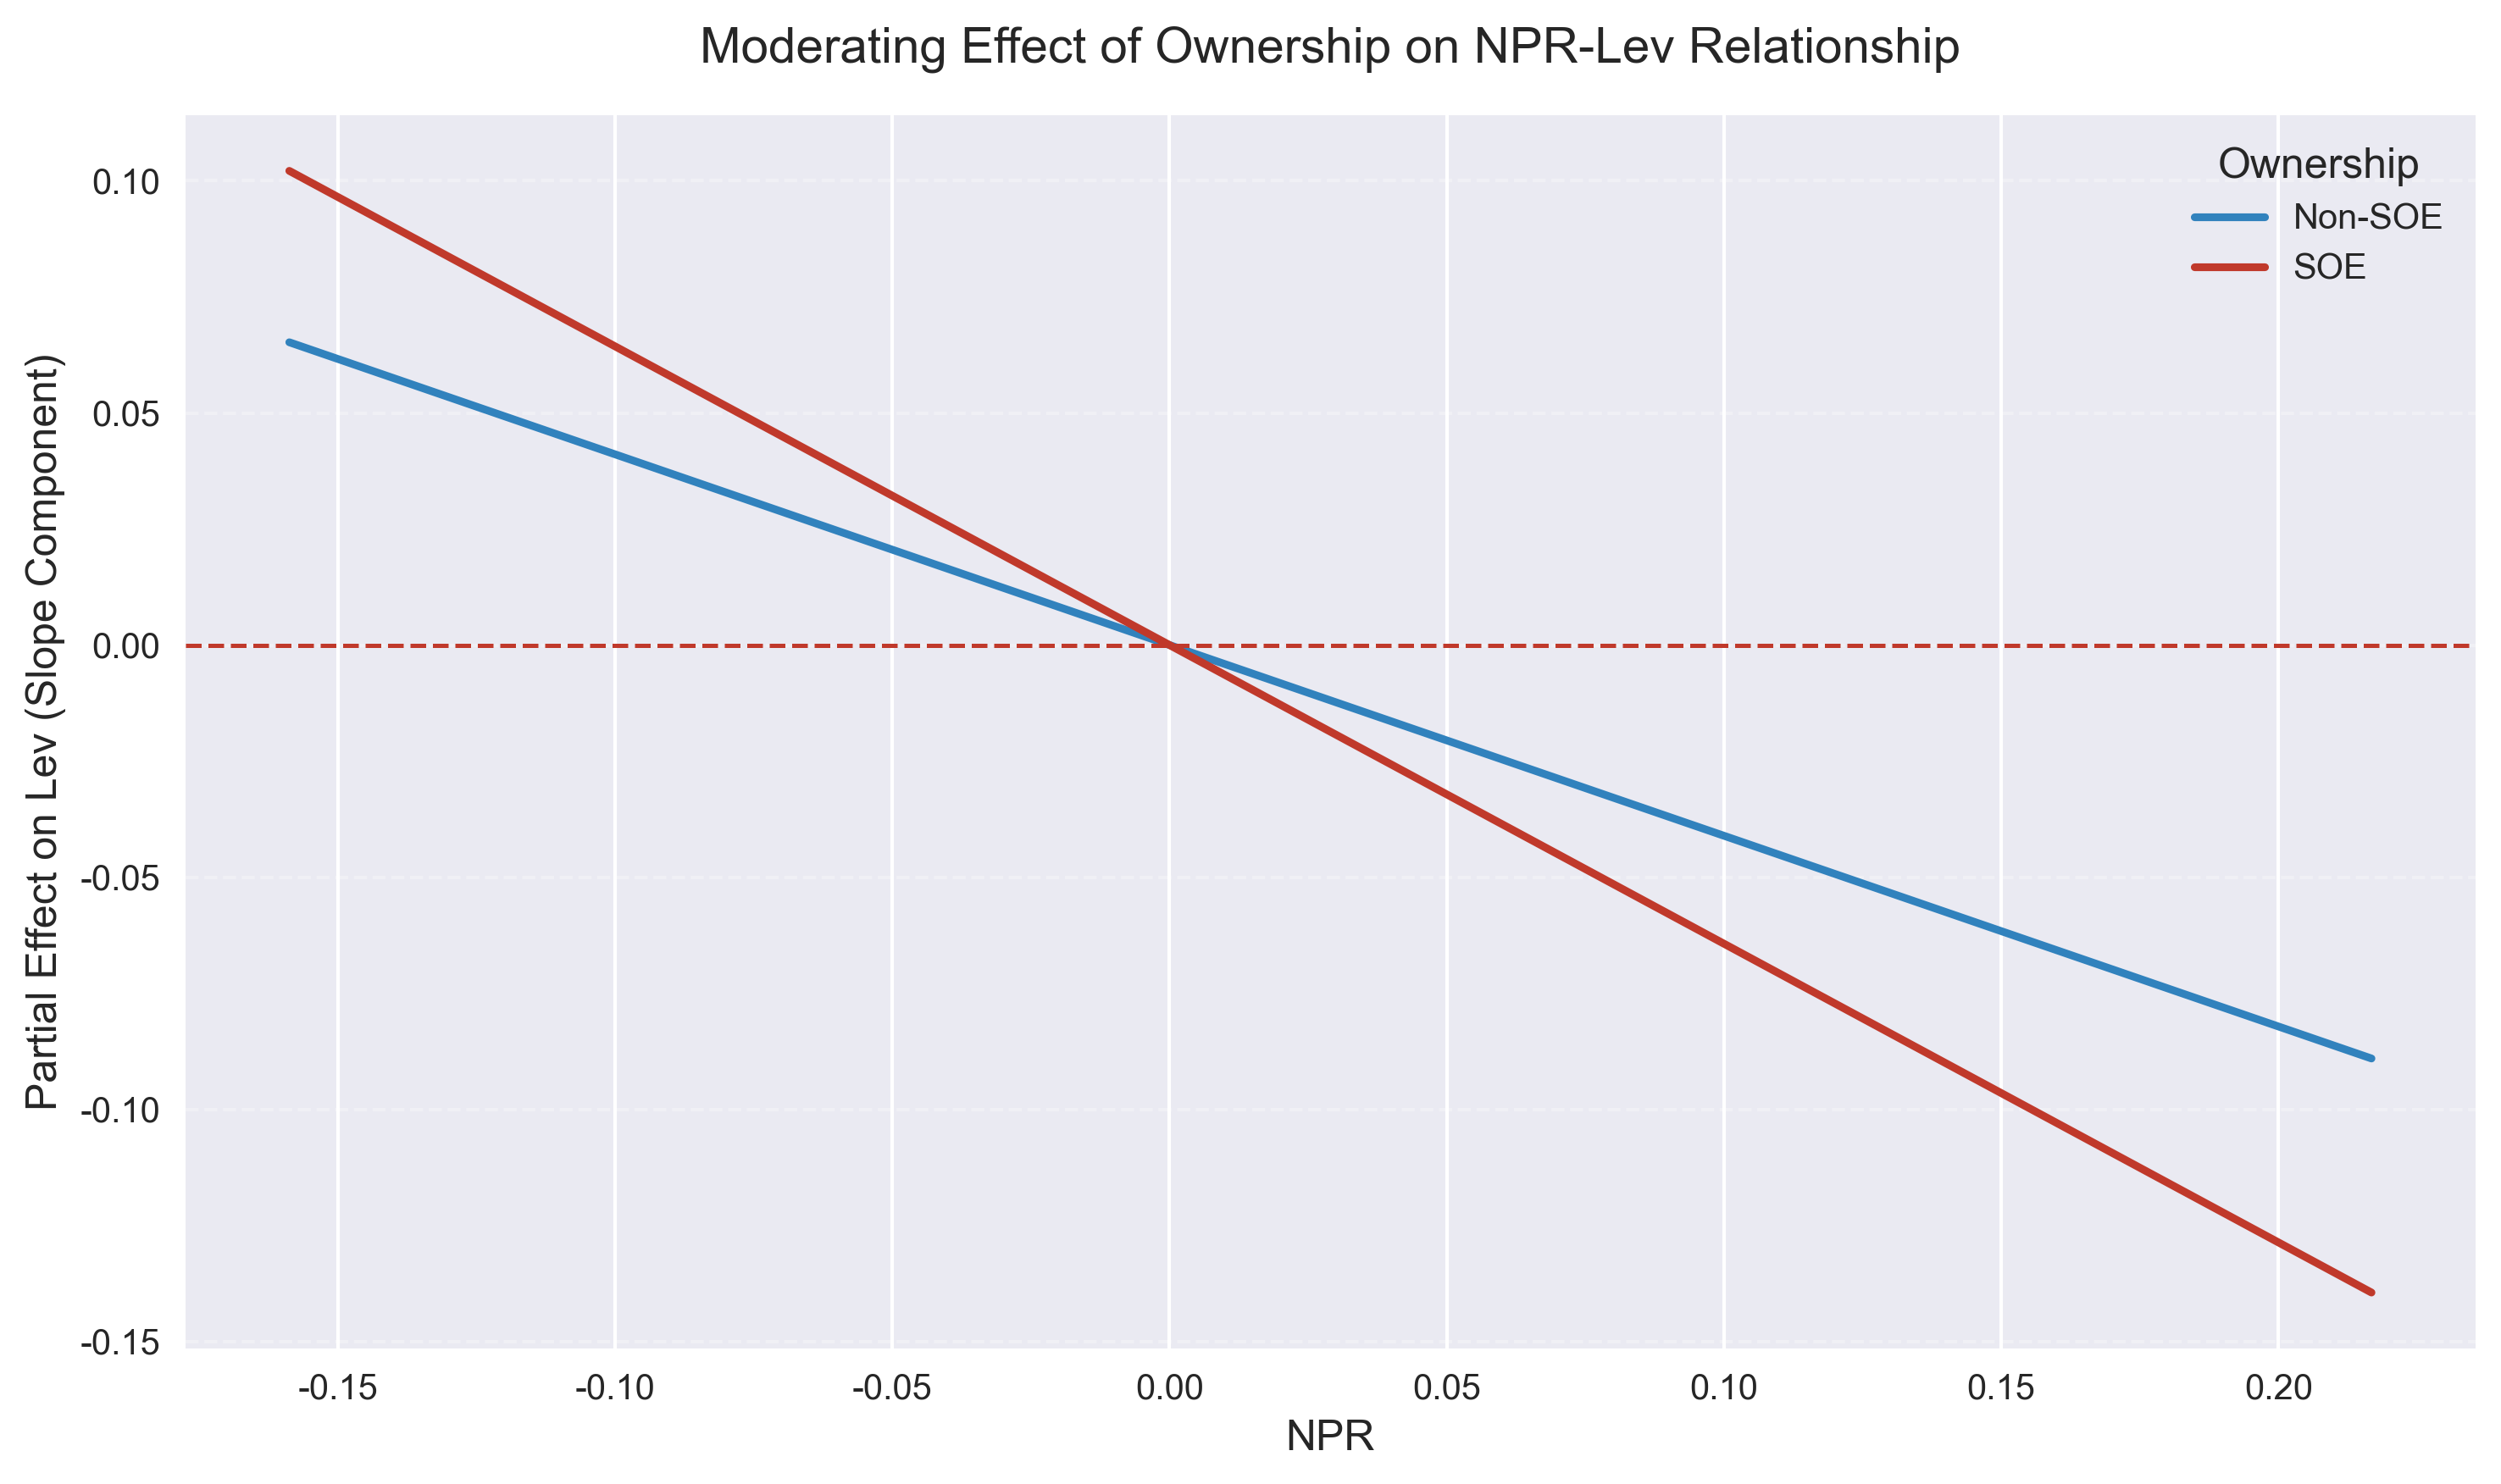

In [10]:
# Create interaction term
df['NPR_SOE'] = df['NPR'] * df['SOE']

# Interaction model (M3)
fit_m3 = feols(
    'Lev ~ NPR + NPR_SOE + SOE + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df,
    vcov={'CRV1': 'Stkcd + year'}
)

print('M3 interaction model results:')
print(fit_m3.summary())

# Save text output
buffer_m3 = StringIO()
sys.stdout = buffer_m3
fit_m3.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m3.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_m3.getvalue())

# Required interpretation quantities: beta1 and beta1+beta2
coefs_m3 = fit_m3.coef()
beta_npr = coefs_m3['NPR'] if 'NPR' in coefs_m3.index else np.nan
beta_inter = coefs_m3['NPR_SOE'] if 'NPR_SOE' in coefs_m3.index else np.nan
beta_soe_slope = beta_npr + beta_inter if pd.notna(beta_npr) and pd.notna(beta_inter) else np.nan

print(f"Slope in Non-SOE (beta1): {beta_npr:.6f}")
print(f"Slope in SOE (beta1 + beta2): {beta_soe_slope:.6f}")

# Moderation effect plot (Fig 4 style)
from plot_config import save_figure, COLORS, remove_top_right_spines
npr_grid = np.linspace(df['NPR'].quantile(0.01), df['NPR'].quantile(0.99), 80)
line_nonsoe = beta_npr * npr_grid
line_soe = beta_soe_slope * npr_grid

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(npr_grid, line_nonsoe, color=COLORS['nonsoe'], linewidth=2.2, label='Non-SOE')
ax.plot(npr_grid, line_soe, color=COLORS['soe'], linewidth=2.2, label='SOE')
ax.axhline(y=0, color=COLORS['accent'], linestyle='--', linewidth=1.2)
remove_top_right_spines(ax)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.title('Moderating Effect of Ownership on NPR-Lev Relationship', fontsize=14, pad=15)
plt.xlabel('NPR', fontsize=12)
plt.ylabel('Partial Effect on Lev (Slope Component)', fontsize=12)
plt.legend(title='Ownership')
plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'moderation_effect_m3.png'))
plt.show()

print('Moderation effect plot saved: output/figures/moderation_effect_m3.png')



### 模型 M4：时变系数模型


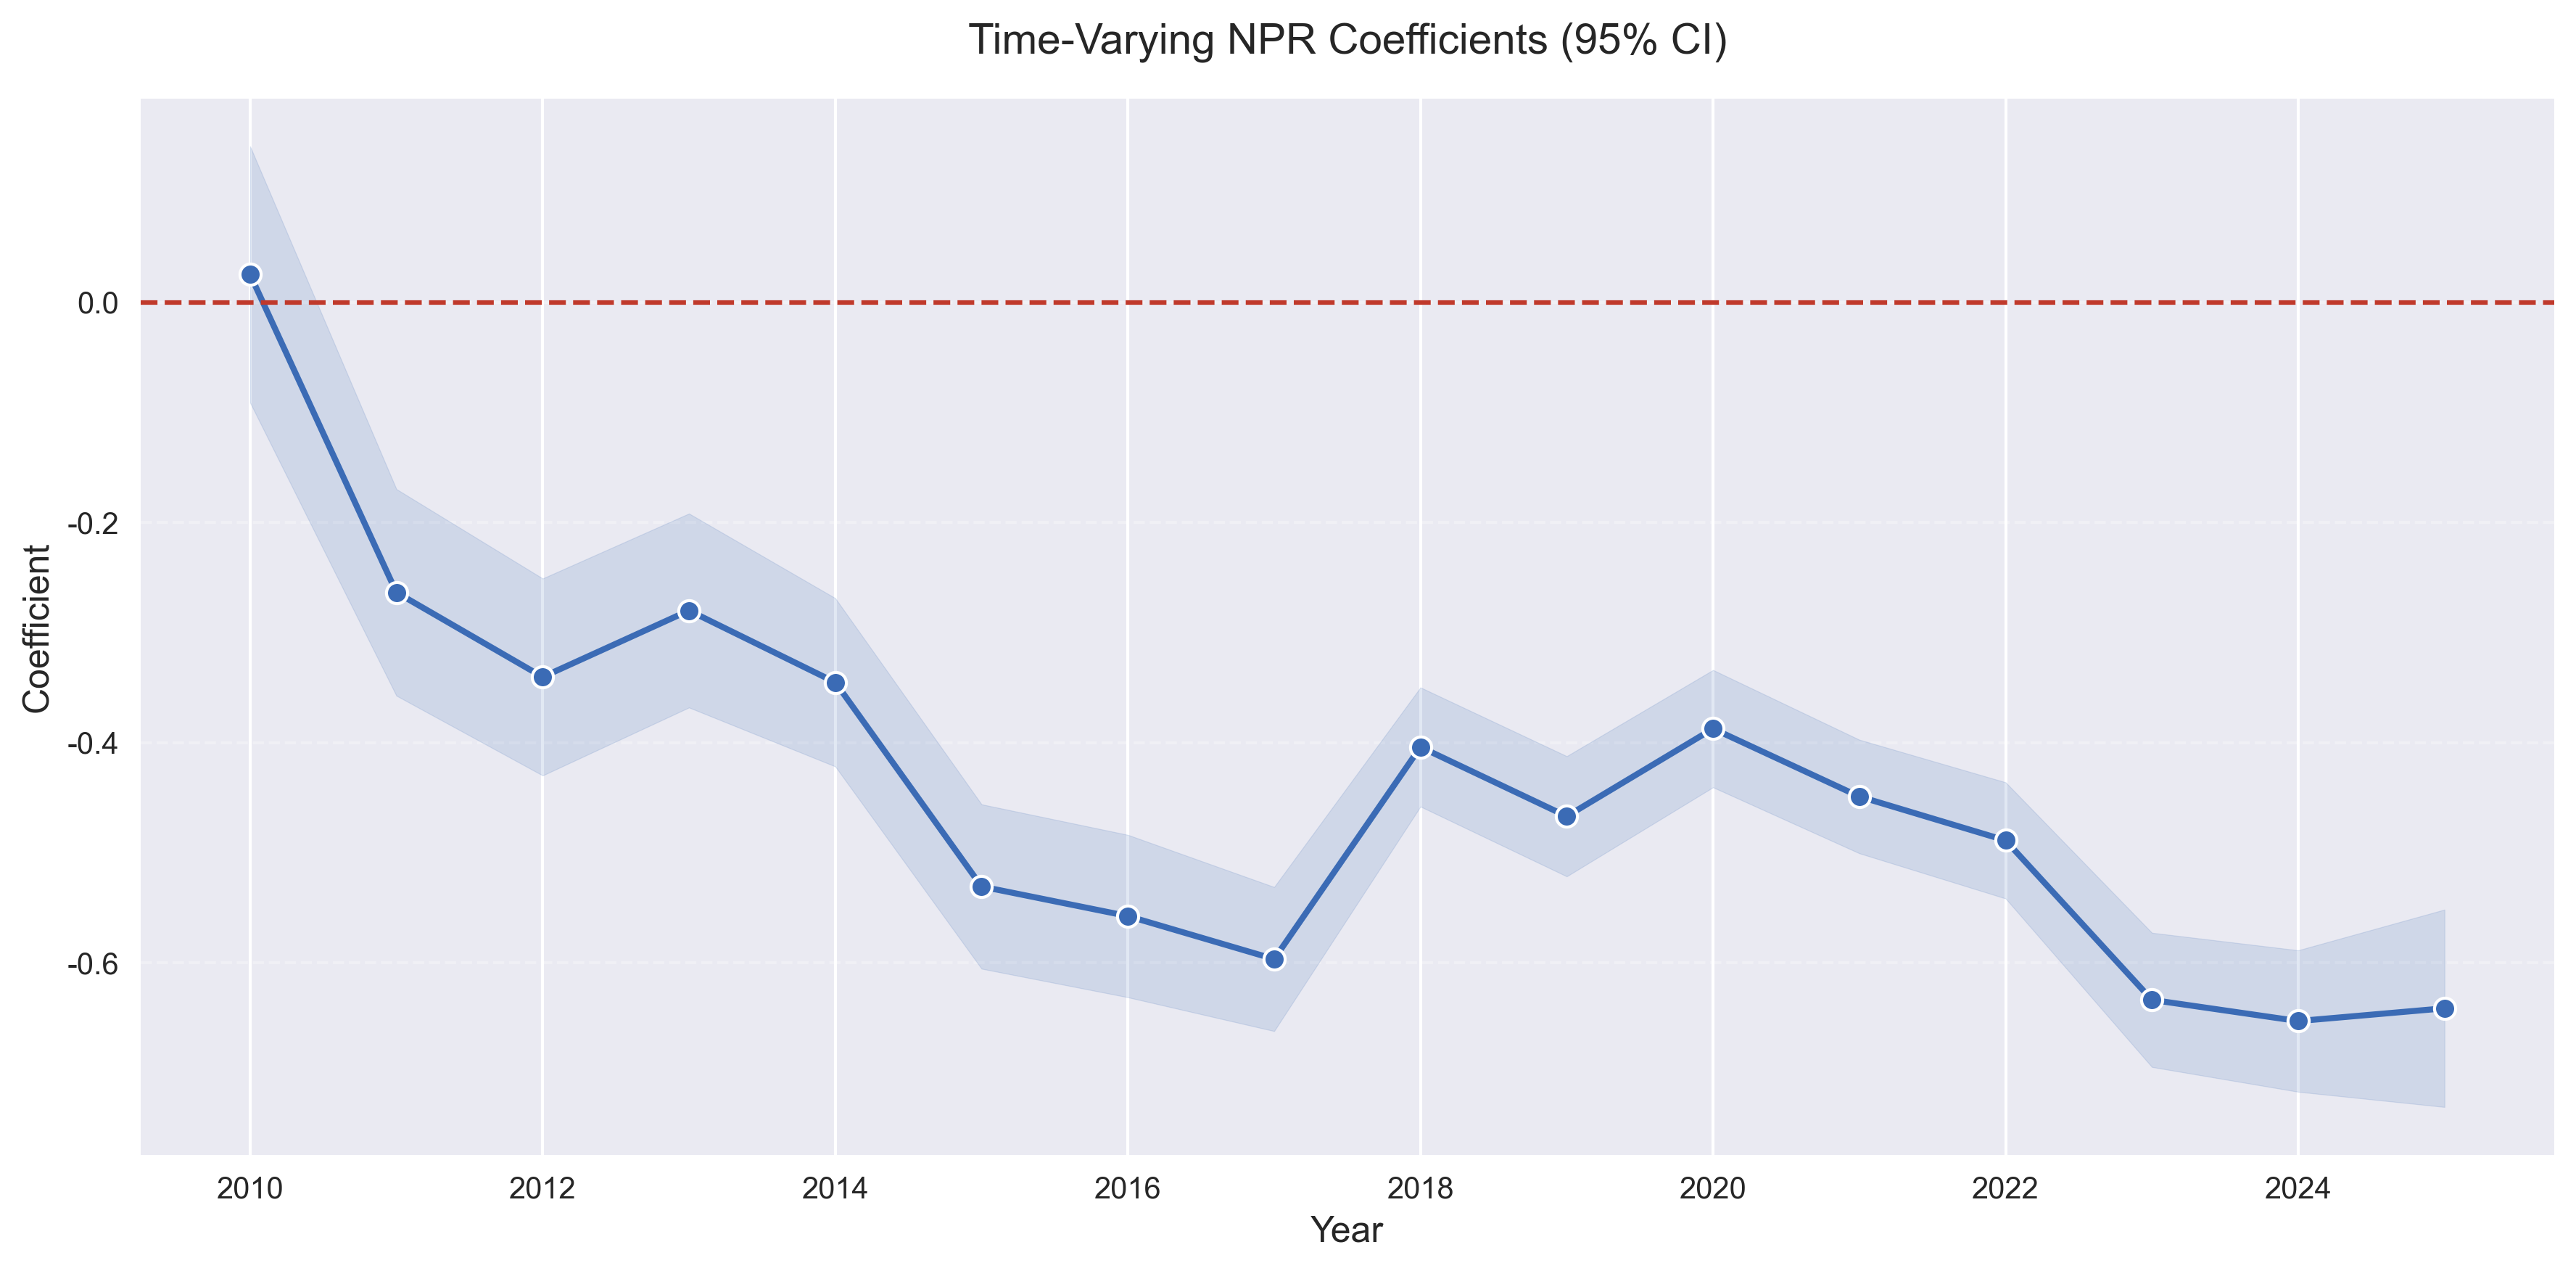

In [11]:
from plot_config import save_figure, COLORS, remove_top_right_spines

# 时变系数模型
# 我们使用年度虚拟变量与 NPR 的交互项来实现
years = sorted(df['year'].unique())
df['year'] = pd.Categorical(df['year'])

# 创建年度虚拟变量
dummies = pd.get_dummies(df['year'], prefix='year')

# 创建交互项
for year in years:
    df[f'NPR_year_{year}'] = df['NPR'] * (df['year'] == year)

# 时变系数模型
time_var_formula = 'Lev ~ ' + ' + '.join([f'NPR_year_{y}' for y in years]) + ' + Size + Tang + Growth + NDTS | Stkcd'

fit_m4 = feols(
    time_var_formula,
    data=df,
    vcov={'CRV1': 'Stkcd'}
)

print('时变系数模型结果:')
print(fit_m4.summary())

# 保存结果
buffer_m4 = StringIO()
sys.stdout = buffer_m4
fit_m4.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m4.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_m4.getvalue())

# 提取年度系数 - 使用 pyfixest 的正确方法
year_coefs = []
for year in years:
    param_name = f'NPR_year_{year}'
    try:
        coefs = fit_m4.coef()
        ses = fit_m4.se()
        tstats = fit_m4.tstat()  # 注意这里需要加括号
        pvalues = fit_m4.pvalue()  # 注意这里需要加括号

        if param_name in coefs.index:
            year_coefs.append({
                'year': year,
                'coef': coefs[param_name],
                'se': ses[param_name],
                't': tstats[param_name],
                'p': pvalues[param_name]
            })
    except Exception as e:
        print(f'提取年份 {year} 系数时出错: {e}')

year_coefs = pd.DataFrame(year_coefs)
if len(year_coefs) > 0:
    year_coefs['ci_lower'] = year_coefs['coef'] - 1.96 * year_coefs['se']
    year_coefs['ci_upper'] = year_coefs['coef'] + 1.96 * year_coefs['se']
    year_coefs['significant'] = year_coefs['p'] < 0.05

    # 绘制时序图 - 使用 plot-from-data 风格
    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    
    # 绘制系数曲线
    ax.plot(year_coefs['year'], year_coefs['coef'], marker='o', linewidth=2, 
            color=COLORS['primary'], markeredgecolor='white', markeredgewidth=1)
    
    # 绘制置信区间阴影
    ax.fill_between(year_coefs['year'], year_coefs['ci_lower'], year_coefs['ci_upper'],
                     color=COLORS['primary'], alpha=0.15)
    
    # 绘制参考线
    ax.axhline(y=0, color=COLORS['accent'], linestyle='--', linewidth=1.5)
    
    # 配置坐标轴
    remove_top_right_spines(ax)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    plt.title('Time-Varying NPR Coefficients (95% CI)', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Coefficient', fontsize=12)
    plt.tight_layout()
    save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'time_varying_coefficients.png'))
    plt.show()

    print('Time-varying coefficient plot saved')
else:
    print('没有成功提取到任何年度系数')

### 模型 M5：函数系数模型（非线性调节效应）


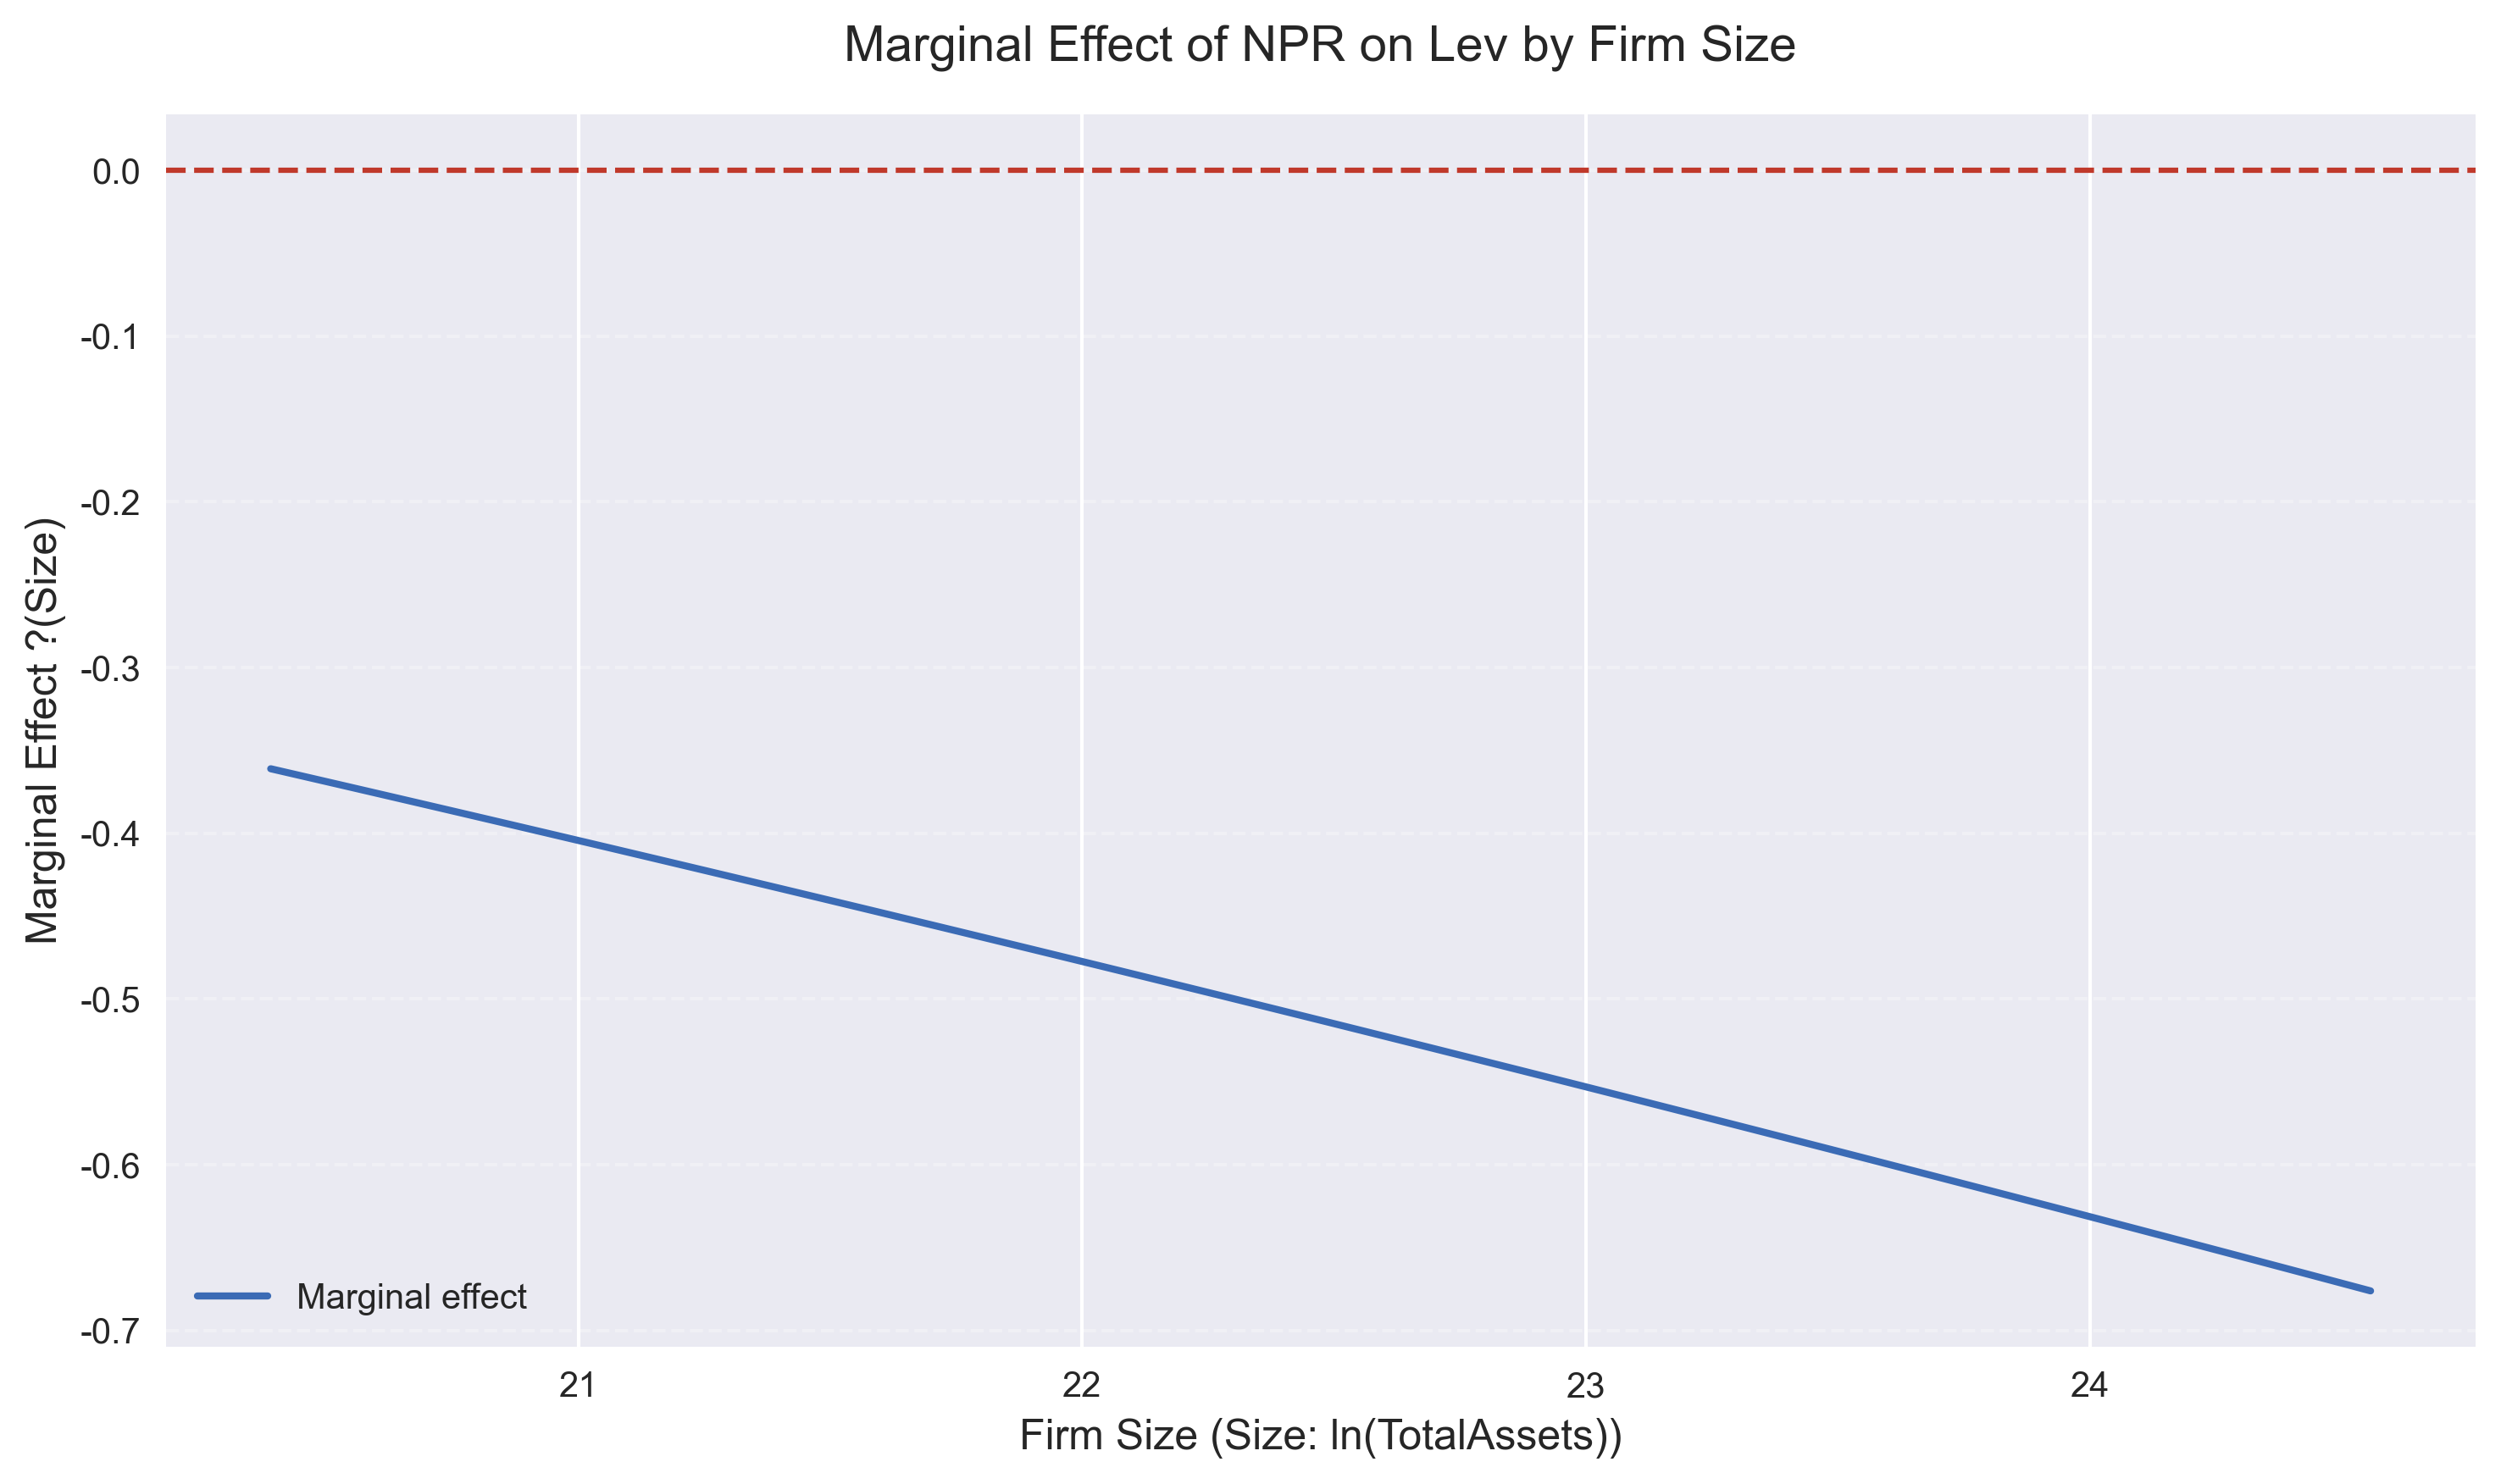

In [12]:
from plot_config import save_figure, COLORS, remove_top_right_spines

# Polynomial moderation (M5)
df['NPR_Size'] = df['NPR'] * df['Size']
df['NPR_Size2'] = df['NPR'] * (df['Size'] ** 2)

fit_m5 = feols(
    'Lev ~ NPR + NPR_Size + NPR_Size2 + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df,
    vcov={'CRV1': 'Stkcd + year'}
)

print('M5 function-coefficient model results:')
print(fit_m5.summary())

# Save text output
buffer_m5 = StringIO()
sys.stdout = buffer_m5
fit_m5.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m5.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_m5.getvalue())

# Marginal effect beta(Size) = b0 + b1*Size + b2*Size^2
coefs = fit_m5.coef()
size_range = np.linspace(df['Size'].quantile(0.05), df['Size'].quantile(0.95), 100)

def marginal_effect(size, params):
    return params['NPR'] + params['NPR_Size'] * size + params['NPR_Size2'] * (size ** 2)

marginal_effects = np.array([marginal_effect(s, coefs) for s in size_range])

# Delta-method confidence band
coef_names = ['NPR', 'NPR_Size', 'NPR_Size2']
ci_lower = np.full_like(size_range, np.nan, dtype=float)
ci_upper = np.full_like(size_range, np.nan, dtype=float)

try:
    vc = fit_m5.vcov()
    if hasattr(vc, 'loc'):
        cov_sub = vc.loc[coef_names, coef_names].values
    else:
        cov_sub = np.asarray(vc)
    for idx, s in enumerate(size_range):
        g = np.array([1.0, s, s ** 2])
        se = np.sqrt(float(g @ cov_sub @ g.T))
        ci_lower[idx] = marginal_effects[idx] - 1.96 * se
        ci_upper[idx] = marginal_effects[idx] + 1.96 * se
except Exception as e:
    print(f'Warning: failed to compute confidence band for M5 ({e})')

# Plot marginal effects with confidence band
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(size_range, marginal_effects, color=COLORS['primary'], linewidth=2, label='Marginal effect')
if np.isfinite(ci_lower).any() and np.isfinite(ci_upper).any():
    ax.fill_between(size_range, ci_lower, ci_upper, color=COLORS['primary'], alpha=0.18, label='95% CI')
ax.axhline(y=0, color=COLORS['accent'], linestyle='--', linewidth=1.5)
remove_top_right_spines(ax)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.title('Marginal Effect of NPR on Lev by Firm Size', fontsize=14, pad=15)
plt.xlabel('Firm Size (Size: ln(TotalAssets))', fontsize=12)
plt.ylabel('Marginal Effect ?(Size)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'marginal_effect_size.png'))
plt.show()

print('Marginal effect plot saved: output/figures/marginal_effect_size.png')



### 模型 M6：门槛模型


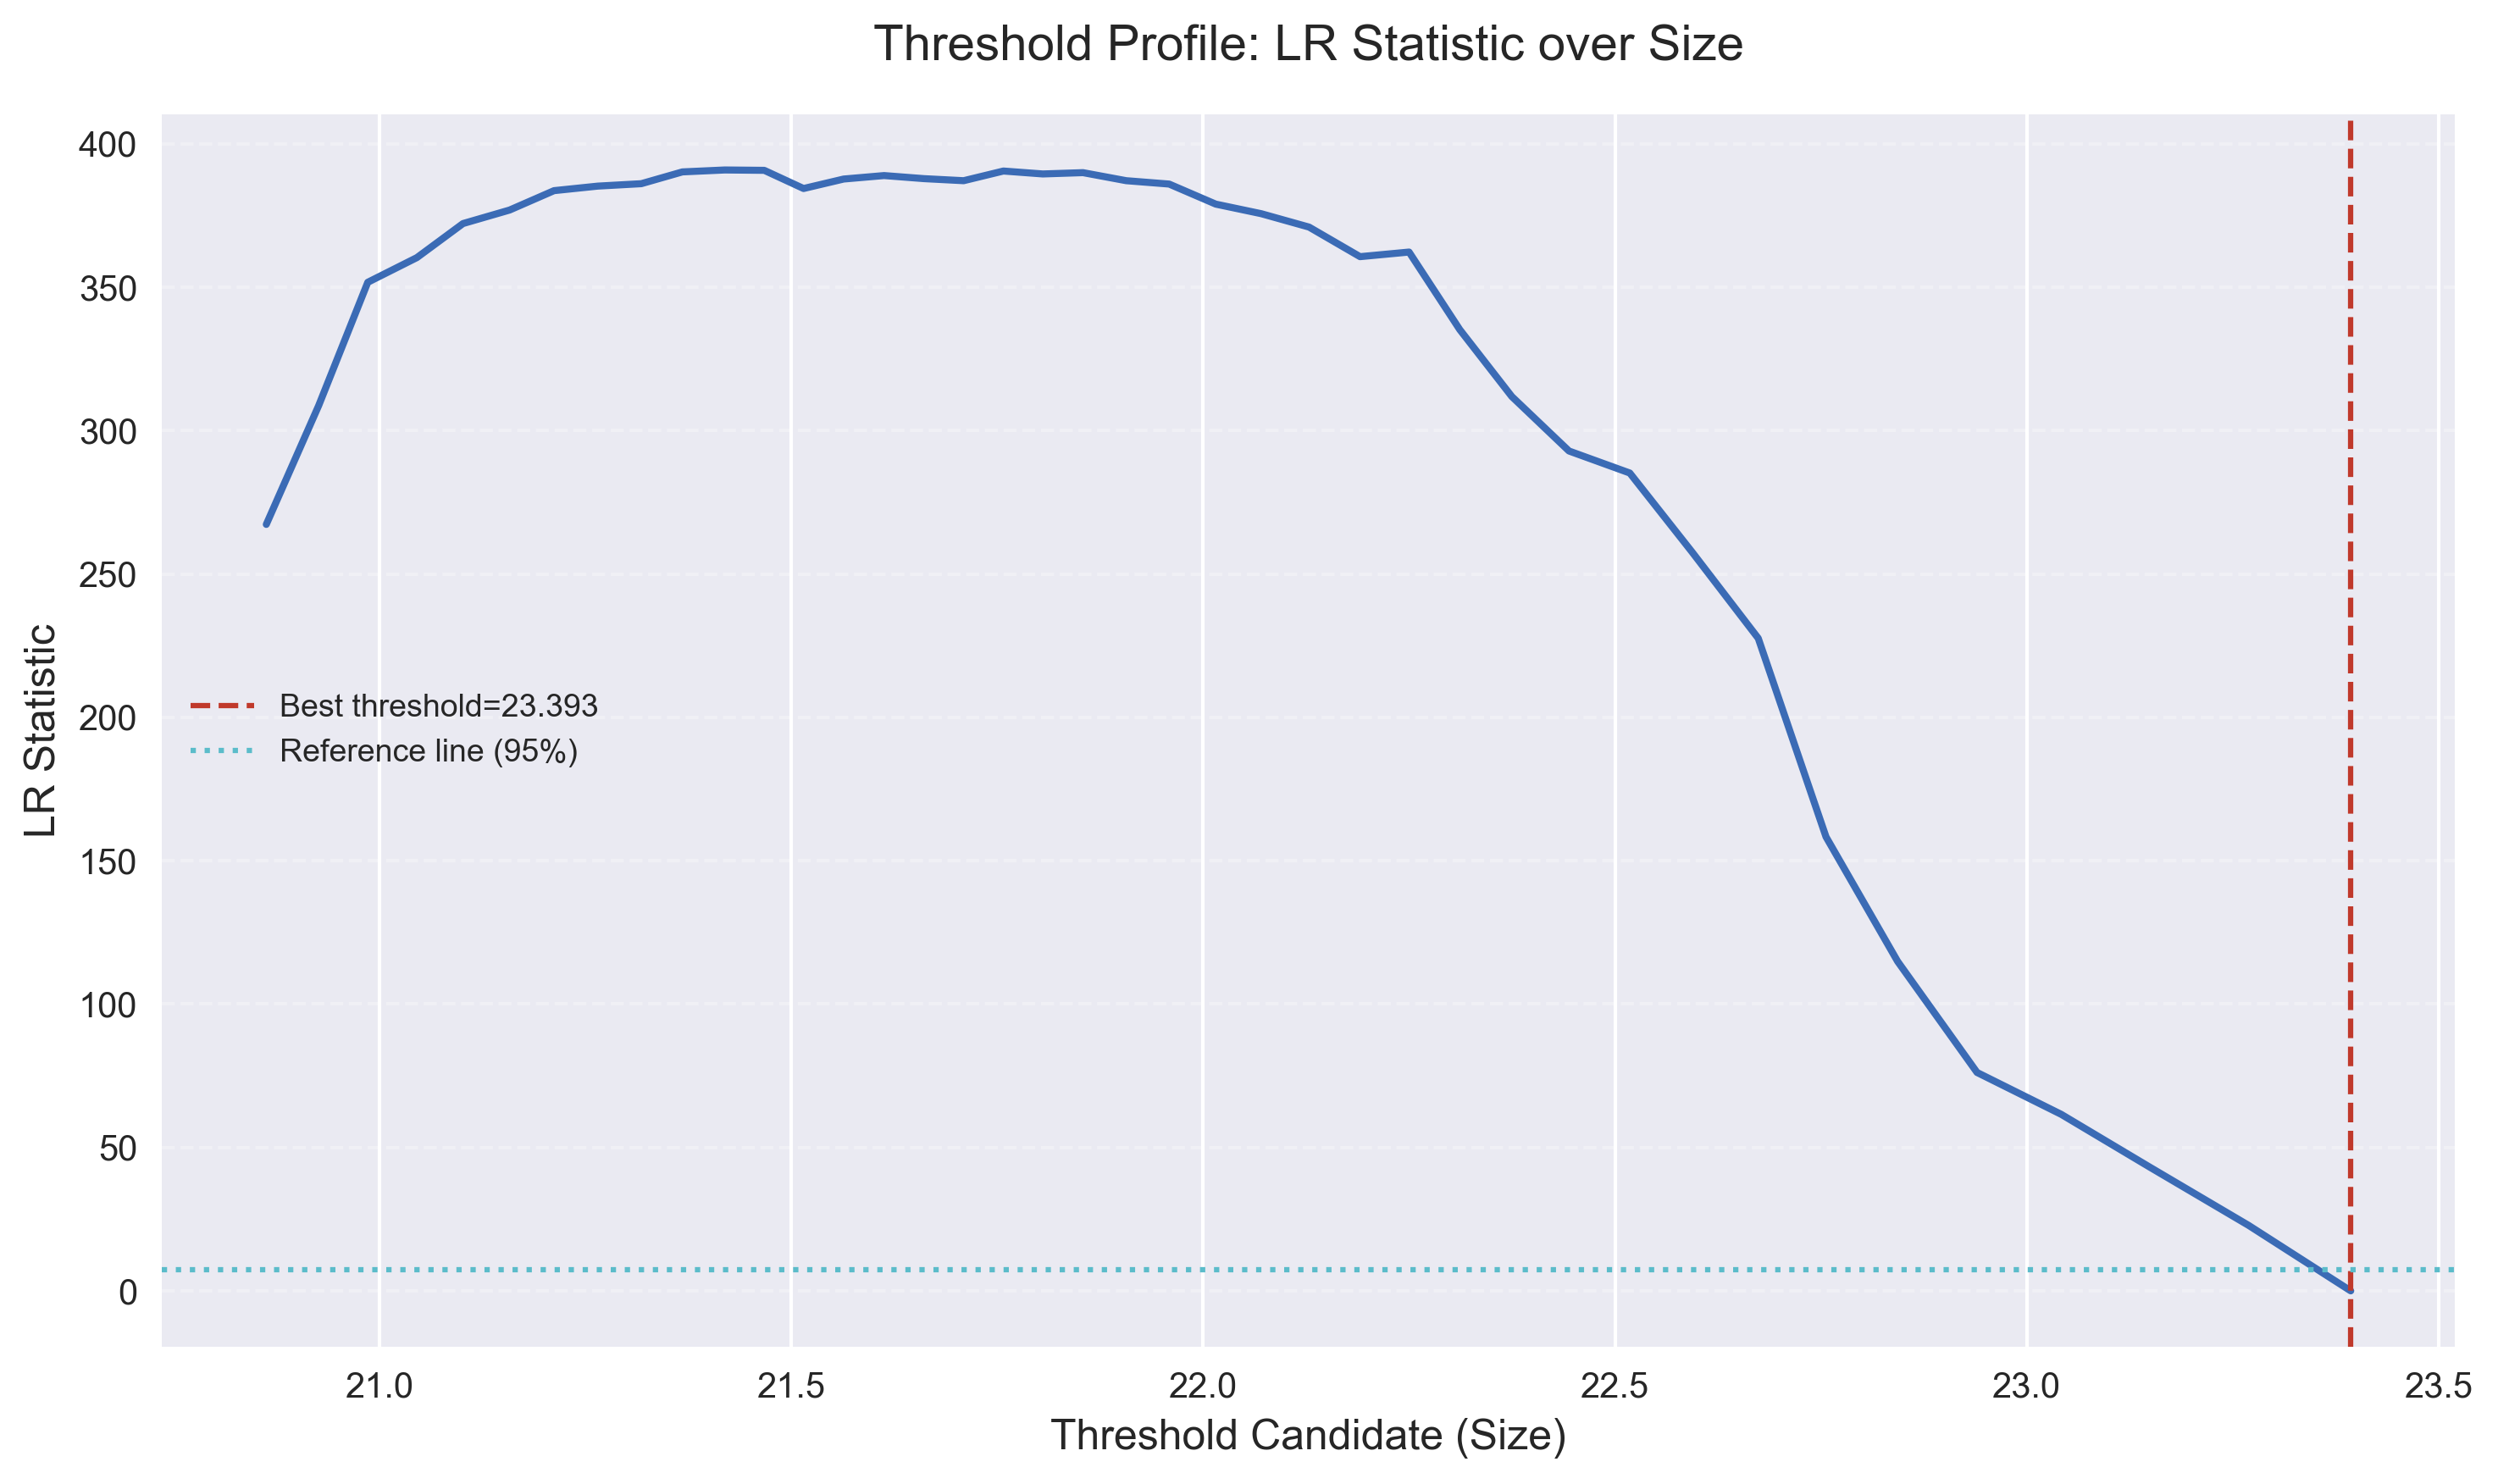

In [13]:
# M6: panel-threshold style robustness check (grid search)
from plot_config import save_figure, COLORS, remove_top_right_spines

# Candidate thresholds (trim 15%-85%)
threshold_grid = np.unique(np.quantile(df['Size'], np.linspace(0.15, 0.85, 40)))


def get_ssr(feols_model):
    resid = None
    if hasattr(feols_model, 'resid'):
        resid = feols_model.resid() if callable(feols_model.resid) else feols_model.resid
    elif hasattr(feols_model, 'residuals'):
        resid = feols_model.residuals() if callable(feols_model.residuals) else feols_model.residuals
    if resid is None:
        raise ValueError('Cannot extract residuals from model object')
    r = np.asarray(resid, dtype=float)
    return float(np.nansum(r ** 2))

# Baseline (no threshold split in NPR slope)
fit_m6_base = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df,
    vcov={'CRV1': 'Stkcd + year'}
)
ssr_base = get_ssr(fit_m6_base)

# Grid search over threshold values
search_records = []
for gamma in threshold_grid:
    temp = df.copy()
    temp['NPR_low'] = temp['NPR'] * (temp['Size'] <= gamma)
    temp['NPR_high'] = temp['NPR'] * (temp['Size'] > gamma)
    try:
        fit_g = feols(
            'Lev ~ NPR_low + NPR_high + Size + Tang + Growth + NDTS | Stkcd + year',
            data=temp,
            vcov={'CRV1': 'Stkcd + year'}
        )
        ssr_g = get_ssr(fit_g)
        search_records.append({'threshold': float(gamma), 'ssr': ssr_g})
    except Exception:
        continue

threshold_results = pd.DataFrame(search_records).sort_values('threshold').reset_index(drop=True)
if threshold_results.empty:
    raise RuntimeError('Threshold search failed: no feasible threshold candidate.')

best_idx = threshold_results['ssr'].idxmin()
best_threshold = threshold_results.loc[best_idx, 'threshold']
ssr_min = threshold_results.loc[best_idx, 'ssr']

print(f'Best threshold (Size): {best_threshold:.6f}')
print(f'Baseline SSR: {ssr_base:.4f}, Min SSR: {ssr_min:.4f}')

# LR-like statistic for visualization (Hansen-style profile plot)
n_obs = len(df)
threshold_results['LR'] = n_obs * (threshold_results['ssr'] - ssr_min) / ssr_min

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(threshold_results['threshold'], threshold_results['LR'], color=COLORS['primary'], linewidth=2)
ax.axvline(best_threshold, color=COLORS['accent'], linestyle='--', linewidth=1.5, label=f'Best threshold={best_threshold:.3f}')
ax.axhline(7.35, color=COLORS['teal'], linestyle=':', linewidth=1.5, label='Reference line (95%)')
remove_top_right_spines(ax)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.title('Threshold Profile: LR Statistic over Size', fontsize=14, pad=15)
plt.xlabel('Threshold Candidate (Size)', fontsize=12)
plt.ylabel('LR Statistic', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'threshold_lr_profile.png'))
plt.show()

# Split sample using the estimated threshold
df['Size_threshold'] = np.where(df['Size'] <= best_threshold, 'small', 'large')
df_small = df[df['Size_threshold'] == 'small']
df_large = df[df['Size_threshold'] == 'large']

fit_m6_small = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df_small,
    vcov={'CRV1': 'Stkcd + year'}
)
fit_m6_large = feols(
    'Lev ~ NPR + Size + Tang + Growth + NDTS | Stkcd + year',
    data=df_large,
    vcov={'CRV1': 'Stkcd + year'}
)

print('M6 small-firm regime results:')
print(fit_m6_small.summary())
print()
print('M6 large-firm regime results:')
print(fit_m6_large.summary())

buffer_m6_small = StringIO()
sys.stdout = buffer_m6_small
fit_m6_small.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m6_small.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_m6_small.getvalue())

buffer_m6_large = StringIO()
sys.stdout = buffer_m6_large
fit_m6_large.summary()
sys.stdout = sys.__stdout__
with open(os.path.join(OUTPUT_PATH, 'model_m6_large.txt'), 'w', encoding='utf-8') as f:
    f.write(buffer_m6_large.getvalue())

threshold_results.to_csv(os.path.join(OUTPUT_PATH, 'm6_threshold_search.csv'), index=False)
print('Saved: output/figures/threshold_lr_profile.png and output/m6_threshold_search.csv')

